# Telco Customer Churn Classification

Problem Statement: 

In the telecom industry, customer retention is paramount. With increasing competition and the ease of switching providers, understanding and predicting customer churn is crucial. Churn, the rate at which customers discontinue their services, directly impacts a company's revenue. By analyzing various factors such as demographics, service usage, and contract terms, we can build predictive models to identify customers at risk of churning.

Aim:

To classify customers as potential churners based on given numerical and categorical features. This is a binary classification problem for an imbalanced dataset.

    



In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option('display.max_columns', 50)

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

<Axes: >

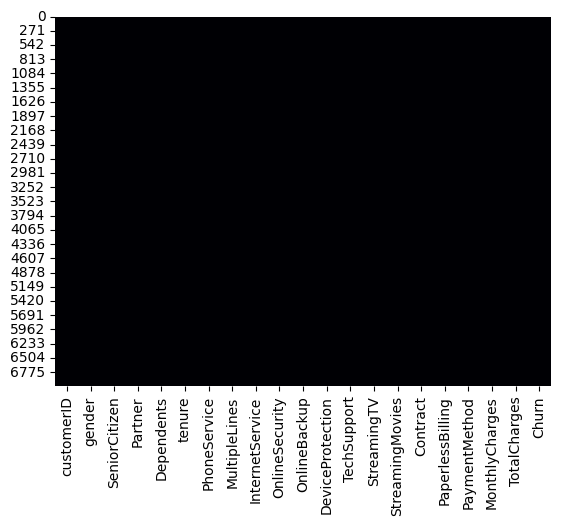

In [7]:
sns.heatmap(df.isnull(), cmap='magma', cbar=False)

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

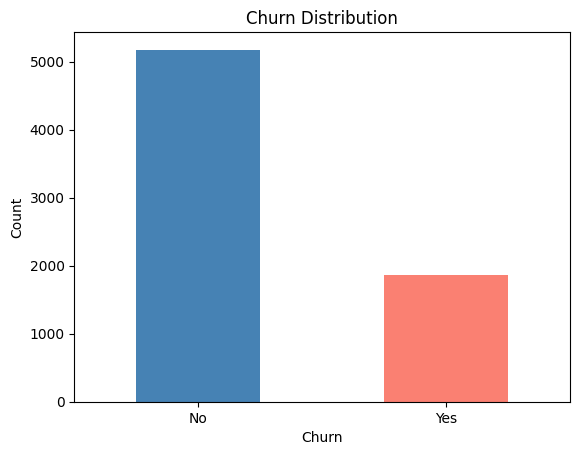

In [11]:
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()

In [13]:
# let's study each column one by one.
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [15]:
df.customerID.describe()

count           7043
unique          7043
top       7590-VHVEG
freq               1
Name: customerID, dtype: object

In [24]:
df.gender.describe(), df.gender.dtype

(count     7043
 unique       2
 top       Male
 freq      3555
 Name: gender, dtype: object,
 <StringDtype(na_value=nan)>)

Text(0, 0.5, 'Count')

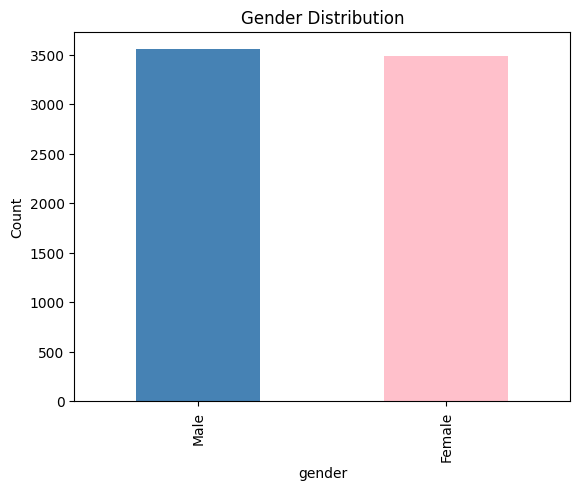

In [23]:
df.gender.value_counts().plot(kind='bar', color=['steelblue', 'pink'])
plt.title('Gender Distribution')
plt.ylabel('Count')


The distribution of gender is quite equal and balanced. and the datatype is string

In [25]:
df.SeniorCitizen.describe()

count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64

In [27]:
df.SeniorCitizen.value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Text(0, 0.5, 'Count')

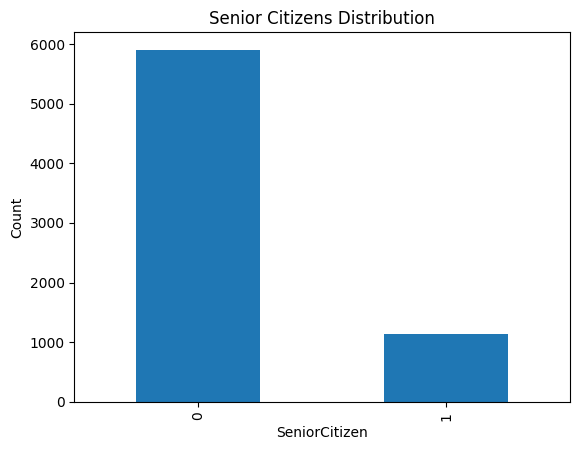

In [91]:
df.SeniorCitizen.value_counts().plot(kind='bar')
plt.title('Senior Citizens Distribution')
plt.ylabel('Count')

There are only few senior citizens and the datatype is int64.

In [34]:
df['Partner'].describe()

count     7043
unique       2
top         No
freq      3641
Name: Partner, dtype: object

In [36]:
df['Partner'].value_counts()

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Text(0, 0.5, 'Count')

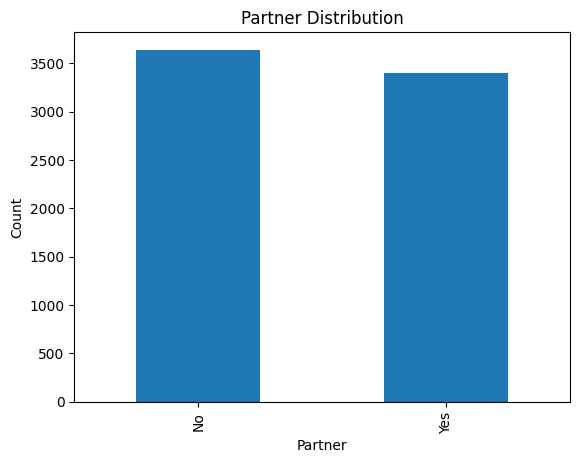

In [90]:
df.Partner.value_counts().plot(kind='bar')
plt.title('Partner Distribution')
plt.ylabel('Count')

The distribution of partner is balanced and the datatype is str.

In [41]:
df.Dependents.describe()

count     7043
unique       2
top         No
freq      4933
Name: Dependents, dtype: object

Text(0, 0.5, 'Count')

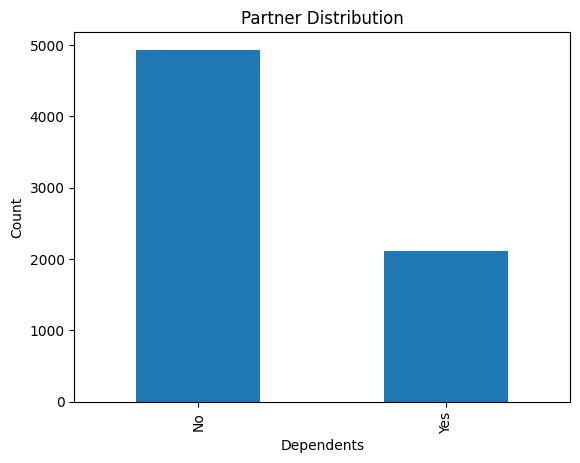

In [89]:
df.Dependents.value_counts().plot(kind='bar')
plt.title('Partner Distribution')
plt.ylabel('Count')

In [43]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [45]:
df.tenure.describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

In [47]:
df.tenure.value_counts().sort_index()

tenure
0      11
1     613
2     238
3     200
4     176
     ... 
68    100
69     95
70    119
71    170
72    362
Name: count, Length: 73, dtype: int64

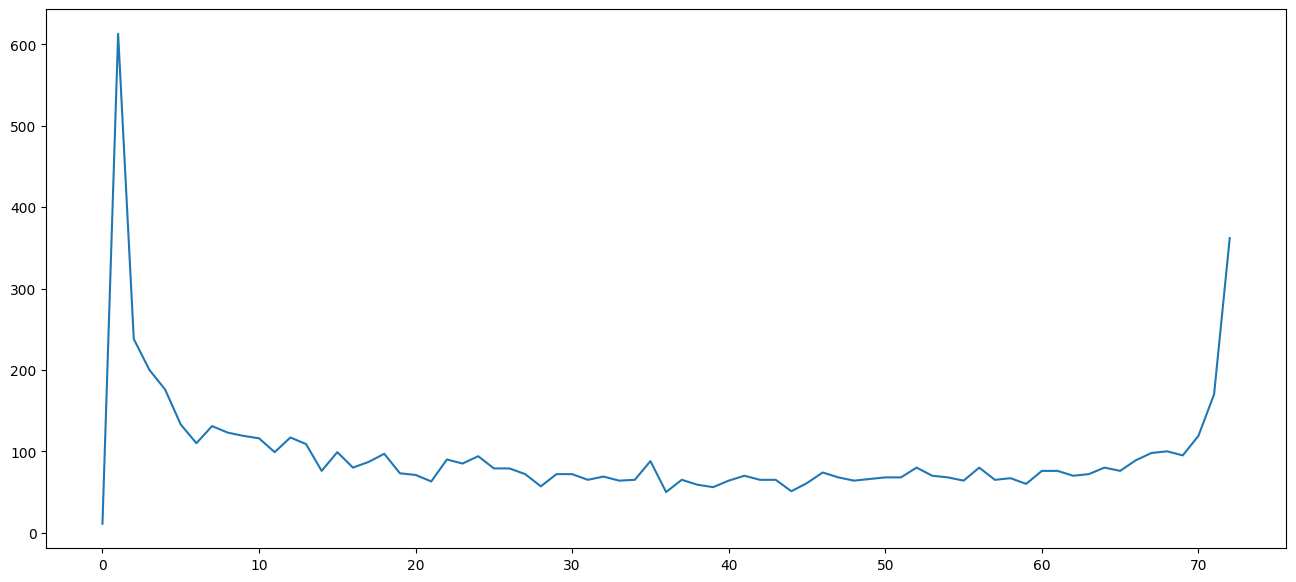

In [60]:
plt.figure(figsize=(16, 7))
plt.plot(df.tenure.value_counts().sort_index().index, df.tenure.value_counts().sort_index().values)
plt.show()

In [61]:
df.PhoneService.describe()

count     7043
unique       2
top        Yes
freq      6361
Name: PhoneService, dtype: object

In [62]:
df.PhoneService.value_counts()

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Mostly every customer do have phone service.

In [63]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [65]:
df.MultipleLines.describe()

count     7043
unique       3
top         No
freq      3390
Name: MultipleLines, dtype: object

In [66]:
df.MultipleLines.value_counts()

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Text(0, 0.5, 'Count')

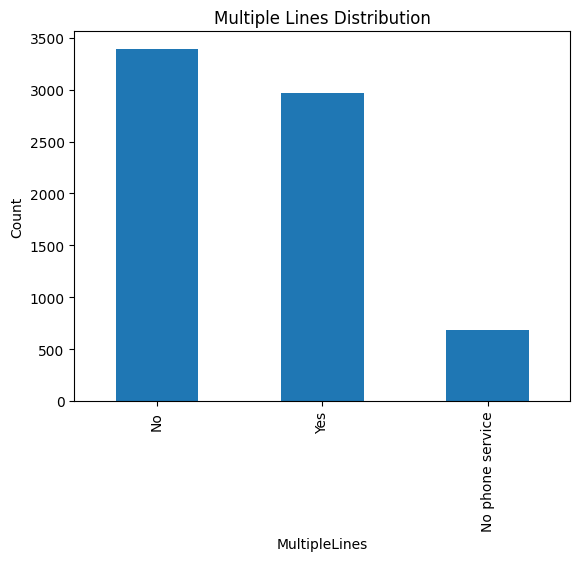

In [67]:
df.MultipleLines.value_counts().plot(kind='bar')
plt.title('Multiple Lines Distribution')
plt.ylabel('Count')

In [68]:
df.InternetService.describe()

count            7043
unique              3
top       Fiber optic
freq             3096
Name: InternetService, dtype: object

In [69]:
df.InternetService.value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [70]:
df.OnlineSecurity.describe()

count     7043
unique       3
top         No
freq      3498
Name: OnlineSecurity, dtype: object

In [71]:
df.OnlineSecurity.value_counts()

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

In [72]:
df.OnlineBackup.describe()

count     7043
unique       3
top         No
freq      3088
Name: OnlineBackup, dtype: object

In [73]:
df.OnlineBackup.value_counts()

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

In [74]:
df.DeviceProtection.describe()

count     7043
unique       3
top         No
freq      3095
Name: DeviceProtection, dtype: object

In [75]:
df.DeviceProtection.value_counts()

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

In [76]:
df.TechSupport.describe()

count     7043
unique       3
top         No
freq      3473
Name: TechSupport, dtype: object

In [77]:
df.TechSupport.value_counts()

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [78]:
df.StreamingTV.describe()

count     7043
unique       3
top         No
freq      2810
Name: StreamingTV, dtype: object

In [79]:
df.StreamingTV.value_counts()

StreamingTV
No                     2810
Yes                    2707
No internet service    1526
Name: count, dtype: int64

In [80]:
df.StreamingMovies.value_counts()

StreamingMovies
No                     2785
Yes                    2732
No internet service    1526
Name: count, dtype: int64

In [81]:
df.Contract.value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [82]:
df.PaperlessBilling.value_counts()

PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

In [83]:
df.PaymentMethod.value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [85]:
df.MonthlyCharges.describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [86]:
df.TotalCharges.describe()

count     7043
unique    6531
top       20.2
freq        11
Name: TotalCharges, dtype: object

TotalCharges should be float not string type.

In [88]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Note: 
* dataset is imbalanced (churn = 1869, not churn = 5174)
* TotalCharges column have wrong datatype.